<a href="https://colab.research.google.com/github/ThanhNgo81-newdata/Carbon-Emission/blob/main/Thanh_Section5_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Import libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np

##Load data

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/sca-programming-school/datasets/main/sales_advertising.csv')

##1. Data Profiling

In [ ]:
df.head()

,tv_ads,radio_ads,newspaper_ads,digital_marketing,sales
0,437.086107,227.135984,149.687216,1099.406439,7753.504975
1,955.642876,263.046047,145.524769,1544.144191,11683.762317
2,758.794548,434.546327,112.930487,1212.800205,8910.744929
3,638.792636,203.001974,250.521225,349.944650,3339.284889
4,240.416776,441.342358,157.564771,534.044426,4361.964031


# Basic information about the dataset (columns, types, numbers of rows and not null values)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   tv_ads             4985 non-null   float64
 1   radio_ads          4982 non-null   float64
 2   newspaper_ads      4977 non-null   float64
 3   digital_marketing  4974 non-null   float64
 4   sales              4982 non-null   float64
dtypes: float64(5)
memory usage: 195.4 KB


In [ ]:
df.describe()

,tv_ads,radio_ads,newspaper_ads,digital_marketing,sales
count,4985.000000,4982.000000,4977.000000,4974.000000,4982.000000
mean,553.657446,271.148836,165.331063,1114.553668,7758.601336
std,309.177632,128.558088,78.497351,518.141180,2788.705500
min,100.010471,50.023772,30.042591,200.454418,1043.825466
25%,321.262698,161.161510,96.729169,674.282712,5483.593562
50%,550.361031,268.687208,163.928071,1124.985865,7836.046852
75%,774.432493,380.026295,235.335541,1552.196991,9986.817587
max,6735.856228,499.777335,299.947389,1999.864688,14322.724102


Cost for tv_ad has the most values under 774 (75%), but the maximum value is far to 6736, it mean the tv_ad has the outliers

## Data Cleaning

## Handling data missing

In [ ]:
df ['tv_ads'] = df ['tv_ads'].fillna(df ['tv_ads'].mean())
df ['radio_ads'] = df ['radio_ads'].fillna(df ['radio_ads'].mean())
df ['newspaper_ads'] = df ['newspaper_ads'].fillna(df ['newspaper_ads'].mean())
df['digital_marketing'] = df['digital_marketing'].fillna(df['digital_marketing'].mean())
df['sales'] = df['sales'].fillna(df['sales'].mean())


## Handling outliers

In [ ]:
Q1 = df['tv_ads'].quantile(0.25)
Q3 = df['tv_ads'].quantile(0.75)
# Calulate
IQR = Q3 - Q1
#Lower and upper bounds for non_outlier caculator
def remove_outliers(df): return df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]
df_cleaned = remove_outliers(df)
print(df_cleaned)

          tv_ads   radio_ads  newspaper_ads  digital_marketing        sales
10    118.526045  124.474899      56.782523         321.598718  1090.559769
133   403.853654   57.212670     182.500945         252.186941  1360.879596
1289  170.720647  253.496795     153.867438         231.129156  1314.853931
2172  257.393293  220.256412     139.914828         207.554889  1043.825466
4856  231.418917   85.337234     191.733412         214.494719  1428.488525


In [ ]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, 10 to 4856
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   tv_ads             5 non-null      float64
 1   radio_ads          5 non-null      float64
 2   newspaper_ads      5 non-null      float64
 3   digital_marketing  5 non-null      float64
 4   sales              5 non-null      float64
dtypes: float64(5)
memory usage: 240.0 bytes


# Correlations

In [ ]:
# calulate the correlation matrix
corr_matrix = df_cleaned.corr()

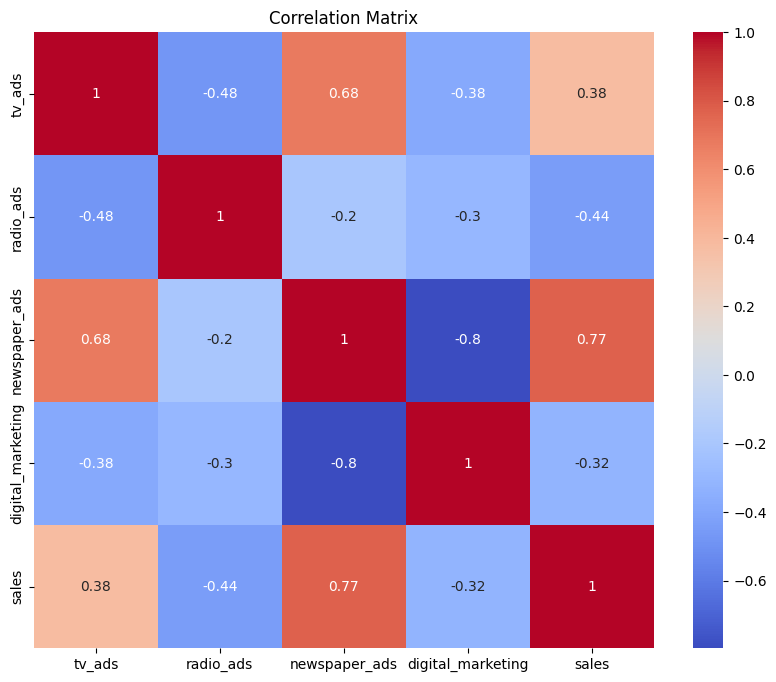

In [ ]:
# Create a heamap using seaborn lib
plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Regression

In [ ]:
x = df_cleaned[['tv_ads', 'radio_ads', 'newspaper_ads', 'digital_marketing']]
y = df_cleaned['sales']

x= sm.add_constant(x)
model = sm.OLS(y, x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Mon, 02 Dec 2024   Prob (F-statistic):                nan
Time:                        10:38:36   Log-Likelihood:                 127.70
No. Observations:                   5   AIC:                            -245.4
Df Residuals:                       0   BIC:                            -247.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              -501.3877        in

/usr/local/lib/python3.10/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/usr/local/lib/python3.10/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/lib/python3.10/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/lib/python3.10/dist-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


## Forecast

## What if we will stop spending for newspaper ads?

In [ ]:
test_data = pd.DataFrame({
    'tv_ads': [500,500],
    'radio_ads': [500,500],
    'newspaper_ads': [500, 0],
    'digital_marketing': [500, 500]
})

test_data = sm.add_constant(test_data, has_constant='add')

predictions = model.predict(test_data)
print(predictions)

0    4400.046876
1    1119.120680
dtype: float64
